C:\Users\elxpa\AppData\Local\Temp\ipykernel_19828\3924084957.py:14: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset([str(p) for p in files], combine='by_coords', parallel=True)


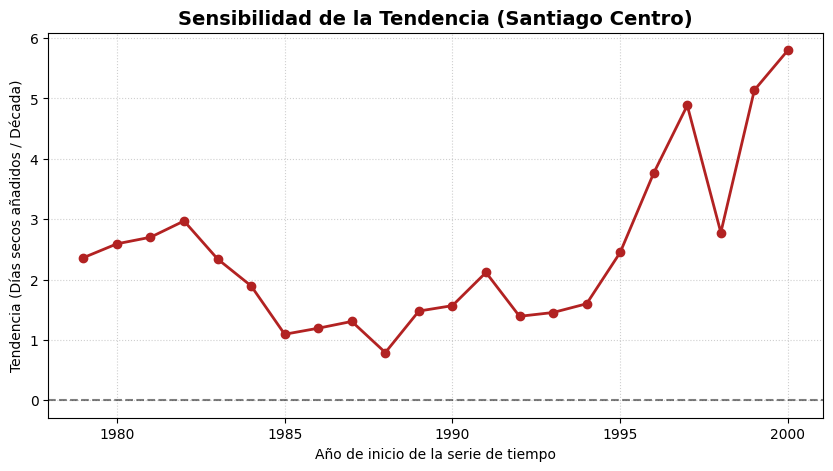

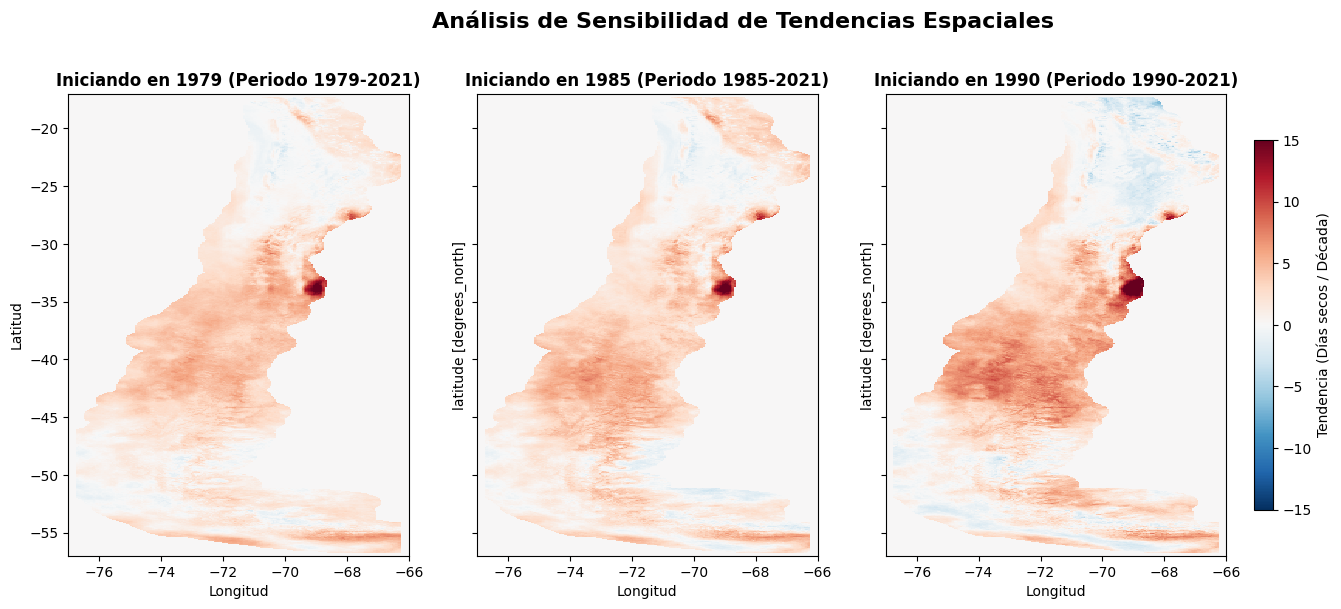

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from pathlib import Path

# =====================================================================
# 1. CARGA DE DATOS Y CÁLCULO DE LA MÉTRICA
# =====================================================================
# Cargar archivos CR2MET (ajusta la ruta si es necesario)
pr_dir = Path('pr')
files = sorted(pr_dir.glob('CR2MET_pr_v2.5_day_*.nc'))
ds = xr.open_mfdataset([str(p) for p in files], combine='by_coords', parallel=True)

# Métrica: Días secos por año (precipitación < 1.0 mm)
# Agrupamos por año y contamos los días
dry_days_per_year = (ds["pr"] < 1.0).groupby("time.year").sum(dim="time")

# =====================================================================
# 2. ANÁLISIS 1D: SENSIBILIDAD DE LA TENDENCIA EN SANTIAGO CENTRO
# =====================================================================
lat_sc = -33.45
lon_sc = -70.66
# Extraer serie temporal para Santiago Centro
dry_days_sc = dry_days_per_year.sel(lat=lat_sc, lon=lon_sc, method="nearest")

# Rango de años de inicio a evaluar (desde 1979 hasta 2000)
anios_inicio = range(1979, 2001) 
tendencias_1d = []

for anio in anios_inicio:
    # Cortar la serie desde el 'anio' de inicio iterado hasta el final (2021)
    serie_recortada = dry_days_sc.sel(year=slice(anio, 2021))
    
    # Calcular regresión lineal (Pendiente)
    slope, intercept, r_val, p_val, std_err = linregress(serie_recortada.year, serie_recortada.values)
    
    # La pendiente (slope) es en [días/año]. Multiplicamos por 10 para [días/década]
    tendencias_1d.append(slope * 10)

# --- Gráfico de Sensibilidad 1D ---
plt.figure(figsize=(10, 5))
plt.plot(anios_inicio, tendencias_1d, marker='o', color='firebrick', lw=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Línea de tendencia cero
plt.title("Sensibilidad de la Tendencia (Santiago Centro)", fontsize=14, fontweight='bold')
plt.xlabel("Año de inicio de la serie de tiempo")
plt.ylabel("Tendencia (Días secos añadidos / Década)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

# =====================================================================
# 3. ANÁLISIS 2D: SENSIBILIDAD ESPACIAL (MAPAS COMPARATIVOS)
# =====================================================================
# Elegimos 3 años de inicio para demostrar que el mapa general no cambia drásticamente
anios_mapas = [1979, 1985, 1990]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, anio in enumerate(anios_mapas):
    # Cortar el dataset espacial entero desde el año de inicio
    ds_espacial = dry_days_per_year.sel(year=slice(anio, 2021))
    
    # Calcular tendencia espacial usando xarray.polyfit (Súper eficiente para mapas)
    # deg=1 hace un ajuste lineal. Seleccionamos degree=1 para obtener la pendiente espacial.
    fit = ds_espacial.polyfit(dim='year', deg=1)
    slope_espacial = fit['polyfit_coefficients'].sel(degree=1)
    
    # Multiplicar por 10 para llevar a [días/década]
    tendencia_decada = slope_espacial * 10
    
    # Graficar mapa
    ax = axes[i]
    # Utilizamos el mapa de colores RdBu_r: Rojo si aumentan los días secos, Azul si disminuyen
    # vmin y vmax mantienen la escala fija entre todos los mapas para poder compararlos
    im = tendencia_decada.plot(ax=ax, cmap="RdBu_r", vmin=-15, vmax=15, add_colorbar=False)
    
    ax.set_title(f"Iniciando en {anio} (Periodo {anio}-2021)", fontweight='bold')
    ax.set_xlabel("Longitud")
    if i == 0:
        ax.set_ylabel("Latitud")

# Añadir una única barra de color global
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.8, pad=0.02)
cbar.set_label('Tendencia (Días secos / Década)')

plt.suptitle("Análisis de Sensibilidad de Tendencias Espaciales", fontsize=16, fontweight='bold', y=1.02)
plt.show()